In [1]:
# %load_ext autoreload
# %autoreload 2

# Эксперимент 1: DiffusionAE

Берем за основу [Time-RCD](https://github.com/thu-sail-lab/Time-RCD/blob/tsb-ad-integration/training.py). В статье она последовательно обучается на большом количестве различных наборов данных последовательно (перенося веса между датасетами). В этом эксперименте обучим просто на наборе данных, предложенных в [DiffusionAE](https://github.com/fbrad/DiffusionAE/tree/main).

In [2]:
import os
import sys
import glob
import json
import shutil
import subprocess
from datetime import datetime

sys.path.append("..")

import torch
import numpy as np

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
assert device == "cuda"

DATA_DIR = "../data/DiffusionAE"
TIME_NOW = datetime.now().strftime('%Y%m%d-%H%M')

os.makedirs(DATA_DIR, exist_ok=True)

In [4]:
from src import TrainingConfig


training_config = TrainingConfig(
    max_seq_len=256,
    overlap_ratio=0.0,
    accumulation_steps=3,
    learning_rate=1e-4, # Appendix, D.4 -- 5e-4
    weight_decay=1e-5,
    batch_size=16,
    num_epochs=50, # Appendix, D.4 -- максимум 50 эпох
    enable_ts_train=True,
    mixed_precision=True,
    checkpoint_dir=None,
    checkpoint_step=-1,
    early_stopping_patience=50,
    verbose=1,
)

training_config.to_dict()

{'batch_size': 16,
 'learning_rate': 0.0001,
 'num_epochs': 50,
 'max_seq_len': 256,
 'overlap_ratio': 0.0,
 'accumulation_steps': 3,
 'weight_decay': 1e-05,
 'enable_ts_train': True,
 'mixed_precision': True,
 'seed': 72,
 'checkpoint_dir': None,
 'checkpoint_step': -1,
 'early_stopping_patience': 50,
 'verbose': 1,
 'max_samples': -1}

In [5]:
from src import DetectorConfig

detector_config = DetectorConfig(
    patch_size=16,
    d_model=512,
    d_proj=256,
    num_layers=8,
    num_heads=8,
    num_features=5,
    channel_strategy="independent"
)

detector_config.to_dict()

{'d_model': 512,
 'd_proj': 256,
 'patch_size': 16,
 'num_query_tokens': 1,
 'num_layers': 8,
 'num_heads': 8,
 'd_ff_dropout': 0.1,
 'use_rope': True,
 'activation': 'gelu',
 'num_features': 5,
 'channel_strategy': 'independent'}

## Модель

In [6]:
from src import Detector

detector = Detector(detector_config)
detector

Detector(
  (ts_encoder): TimeSeriesEncoderIndependent(
    (embedding_layer): Linear(in_features=16, out_features=512, bias=True)
    (rope_embedder): RoPELayer()
    (transformer_encoder): CustomTransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayerWithRoPE(
          (self_attn): MultiheadAttentionWithRoPE(
            (q_proj): Linear(in_features=512, out_features=512, bias=False)
            (k_proj): Linear(in_features=512, out_features=512, bias=False)
            (v_proj): Linear(in_features=512, out_features=512, bias=False)
            (out_proj): Linear(in_features=512, out_features=512, bias=False)
            (binary_attention_bias): BinaryAttentionBias(
              (emd): Embedding(2, 8)
            )
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (input_norm): RMSNorm((512,), eps=None, elementwise_affine=True)
          (output_norm): RMSNorm((512,), eps=None, elementwise_affine=True)
          (mlp): LlamaM

In [7]:
print(sum(p.numel() for p in detector.parameters()))
del detector

37023361


## Загрузка данных

In [8]:
# subprocess.run([
#     'git', 'clone', 'https://github.com/fbrad/DiffusionAE.git', f"{DATA_DIR}/tmp_repo"
# ], check=True)
# shutil.copytree(f'{DATA_DIR}/tmp_repo/DiffusionAE/processed', DATA_DIR, dirs_exist_ok=True)
# shutil.rmtree(f"{DATA_DIR}/tmp_repo/")

## Формат данных

https://arxiv.org/pdf/2311.01452

**Синтетика**

| Dataset    | Anomaly type | Train     | Valid  |  Test   | \|D\| | Anomalies in train | Anomalies in test |
|------------|--------------|-----------| ------ | --------|-------|--------------------|-------------------|
| Global     | point        | 20,000    | 10,000 |  20,000 | 5     | +                  | 6%                |
| Contextual | point        | 20,000    | 10,000 |  20,000 | 5     | +                  | 6%                |
| Seasonal   | point        | 20,000    | 10,000 |  20,000 | 5     | +                  | 6%                |
| Shapelet   | point        | 20,000    | 10,000 |  20,000 | 5     | +                  | 5%                |
| Trend      | pattern      | 20,000    | 10,000 |  20,000 | 5     | +                  | 6%                |

Синтезировано по 50к наблюдений в каждом. Размерность везде 5, но аномалии содержит лишь одна из них. Выборки стратифицированы по доле анормальности.

## Подготовка данных

In [9]:
from src import get_DAE_loaders

FOLDERS = glob.glob(f"{DATA_DIR}/*") #[1:2]
loaders = {
    os.path.split(fld)[-1]: get_DAE_loaders(fld, training_config)
    for fld in FOLDERS
}

pattern_seasonal
    X_train: (78, 256, 5)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
     y_test: (78, 256)

pattern_shapelet
    X_train: (78, 256, 5)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
     y_test: (78, 256)

pattern_trendv2
    X_train: (78, 256, 5)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
     y_test: (78, 256)

point_contextual
    X_train: (78, 256, 5)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
     y_test: (78, 256)

point_global
    X_train: (78, 256, 5)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
     y_test: (78, 256)



## Обучение

In [10]:
from src import (
    train_worker,
    plot_training_results,
)

from tensorboard_utils import (
    init_tensorboard,
    log_losses,
)

In [11]:
from src import train_epoch

detector = Detector(detector_config).to(device)
optimizer = torch.optim.AdamW(
    detector.parameters(),
    lr=training_config.learning_rate,
    weight_decay=training_config.weight_decay
)
scaler = torch.amp.GradScaler() if training_config.mixed_precision else None

train_epoch(training_config, detector, optimizer, loaders["pattern_shapelet"]["train"], device=device, epoch=1, scaler=scaler)

0.9695576071739197

Dataset PATTERN_SEASONAL already trained!
Dataset PATTERN_SHAPELET already trained!
Dataset PATTERN_TRENDV2 already trained!
Training POINT_CONTEXTUAL dataset...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [34:08<00:00, 40.98s/it]


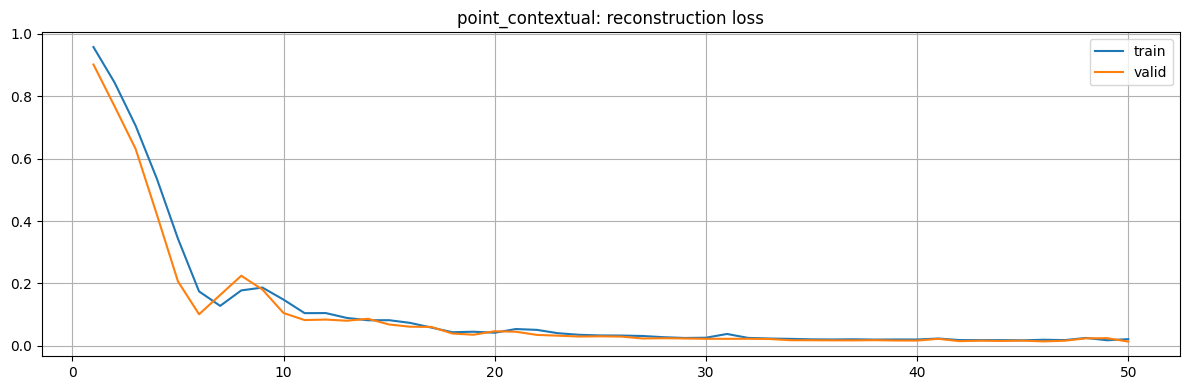

Training POINT_GLOBAL dataset...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [34:27<00:00, 41.36s/it]


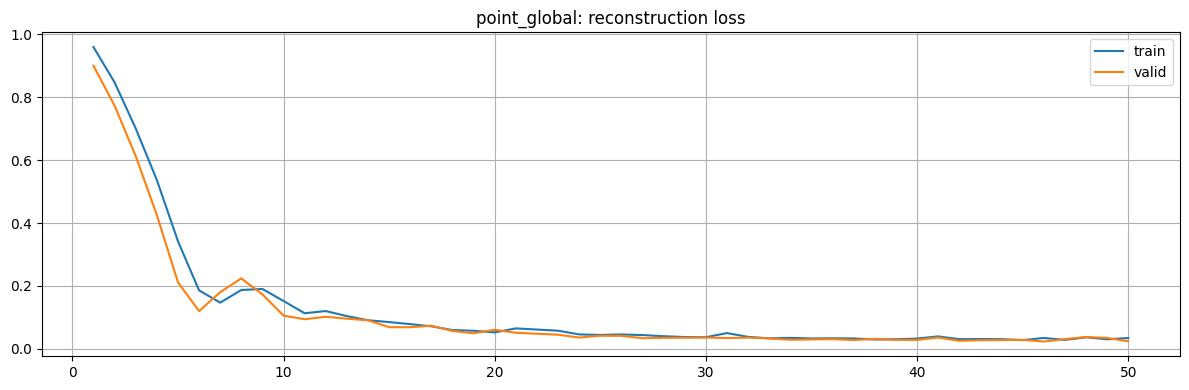

In [12]:
for dataset in loaders:
    if dataset in ["pattern_seasonal", "pattern_shapelet", "pattern_trendv2"]: 
        print(f"Dataset {dataset.upper()} already trained!")
        continue
    
    print(f"Training {dataset.upper()} dataset...")
    
    tb_writer = init_tensorboard(f"{dataset}/{TIME_NOW}")
    
    train_loader = loaders[dataset]["train"]
    valid_loader = loaders[dataset]["valid"]
    training_config.checkpoint_dir = f"DiffusionAE/{dataset}-{detector_config.channel_strategy}"

    # Обучаем
    detector = Detector(detector_config)
    losses = train_worker(training_config, detector, train_loader, valid_loader, device=device)
    
    # Логируем лоссы
    plot_training_results(losses, title_prefix=dataset)
    log_losses(tb_writer, losses)

    torch.cuda.empty_cache()
    del detector

## Метрики

In [13]:
from src import benchmark, load_checkpoint
from tensorboard_utils import log_hparams


def benchmark_dataset(dataset):
    print(f"Benchmarking {dataset} dataset...")
    tb_writer = init_tensorboard(f"{dataset}/{TIME_NOW}")

    # Подгружаем чекпоинт
    detector = Detector(detector_config).to(device)
    optimizer = torch.optim.AdamW(
        detector.parameters(),
        lr=training_config.learning_rate,
        weight_decay=training_config.weight_decay
    )
    scaler = torch.amp.GradScaler() if training_config.mixed_precision else None

    training_config.checkpoint_dir = f"DiffusionAE/{dataset}-{detector_config.channel_strategy}"
    checkpoint_path = f"{training_config.checkpoint_dir}/pretrain_checkpoint_best.pth"
    checkpoint = load_checkpoint(training_config, detector, optimizer, scaler, checkpoint_path, device, strict=True)

    # Логируем конфиги и метрики
    metrics = benchmark(detector, loaders[dataset]["valid"], loaders[dataset]["test"], device)
    log_hparams(tb_writer, detector_config, training_config, metrics)

    print(f"{dataset} metrics:")
    for k, v in metrics.items():
        print(f"{k:<20}:\t{v:.4f}")
    print()


def benchmark_all_datasets():
    for dataset in loaders:
        benchmark_dataset(dataset)

In [14]:
benchmark_all_datasets()

Benchmarking pattern_seasonal dataset...
pattern_seasonal metrics:
RMSE                :	0.3438
MAE                 :	0.2691
AUC-ROC             :	0.8098
F1                  :	0.5767
Precision           :	0.8790
Recall              :	0.4291
t>                  :	0.3532

Benchmarking pattern_shapelet dataset...
pattern_shapelet metrics:
RMSE                :	0.1315
MAE                 :	0.1002
AUC-ROC             :	0.7469
F1                  :	0.4094
Precision           :	0.8700
Recall              :	0.2677
t>                  :	0.0620

Benchmarking pattern_trendv2 dataset...
pattern_trendv2 metrics:
RMSE                :	0.2867
MAE                 :	0.1851
AUC-ROC             :	0.8777
F1                  :	0.7230
Precision           :	0.9061
Recall              :	0.6015
t>                  :	0.2300

Benchmarking point_contextual dataset...
point_contextual metrics:
RMSE                :	0.1289
MAE                 :	0.0940
AUC-ROC             :	0.8770
F1                  :	0.6201
Precis

## Визуализация

In [15]:
from src import visualize_batch_sample


def show_example(dataset):
    detector = Detector(detector_config).to(device)
    optimizer = torch.optim.AdamW(
        detector.parameters(),
        lr=training_config.learning_rate,
        weight_decay=training_config.weight_decay
    )
    scaler = torch.amp.GradScaler() if training_config.mixed_precision else None

    checkpoint_dir = f"DiffusionAE/{dataset}-{detector_config.channel_strategy}"
    checkpoint_path = f"{checkpoint_dir}/pretrain_checkpoint_best.pth"
    checkpoint = load_checkpoint(training_config, detector, optimizer, scaler, checkpoint_path, device, strict=True)

    it = iter(loaders[dataset]["test"])
    batch = next(it)
    visualize_batch_sample(detector, batch, sample_idx=0)

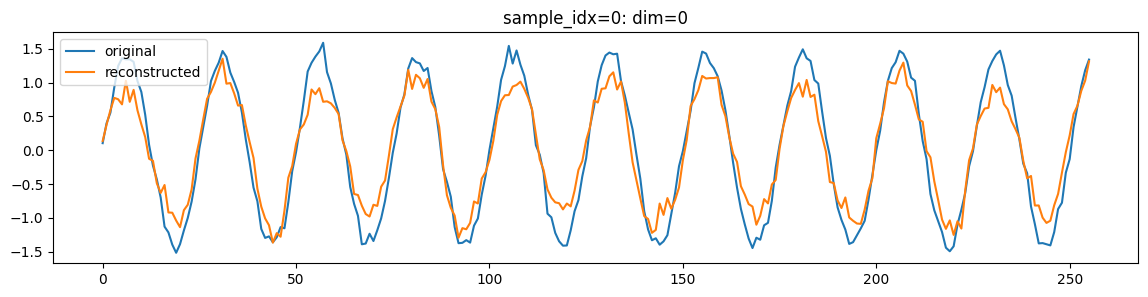

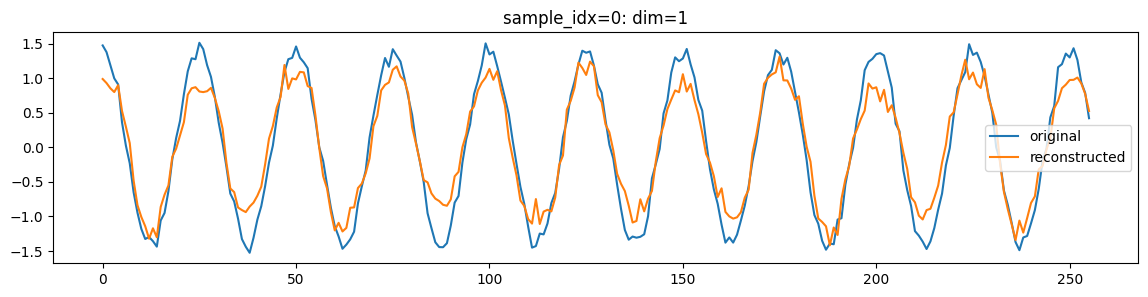

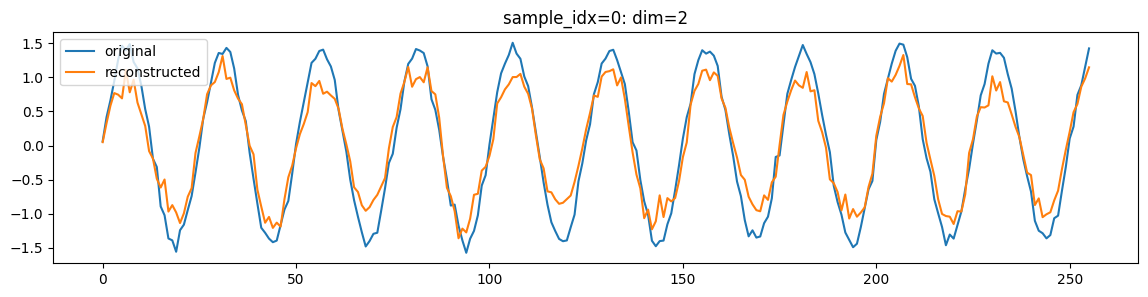

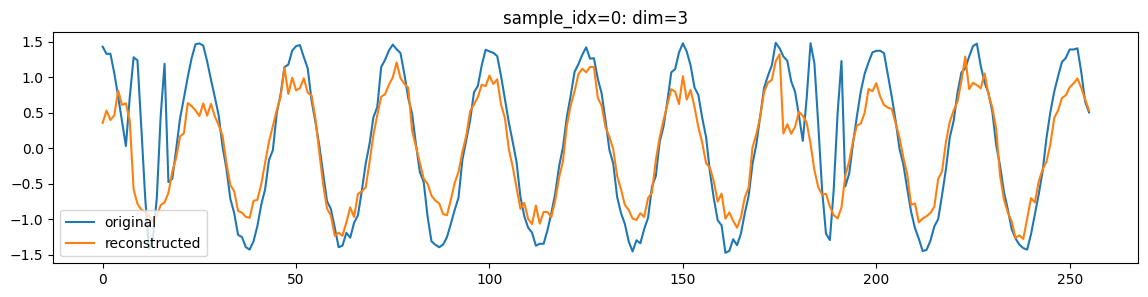

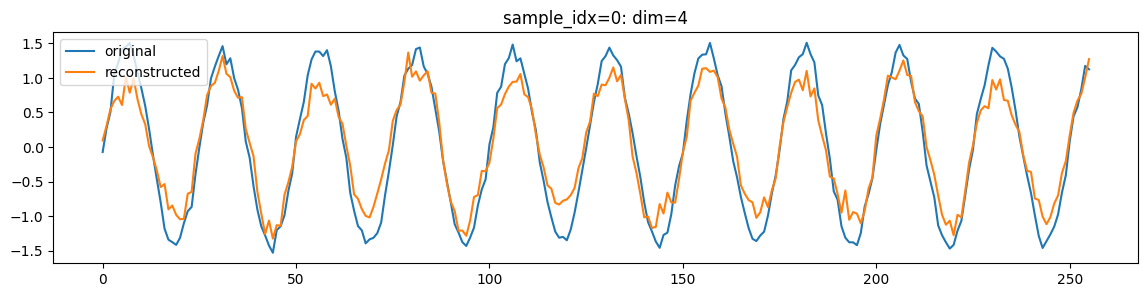

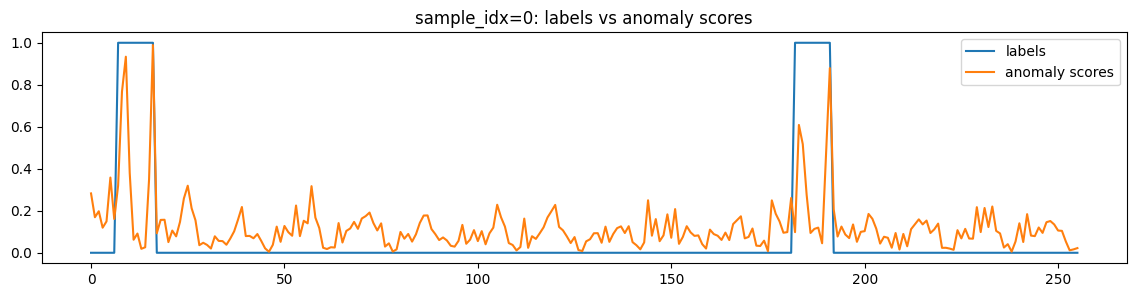

In [16]:
show_example("pattern_seasonal")

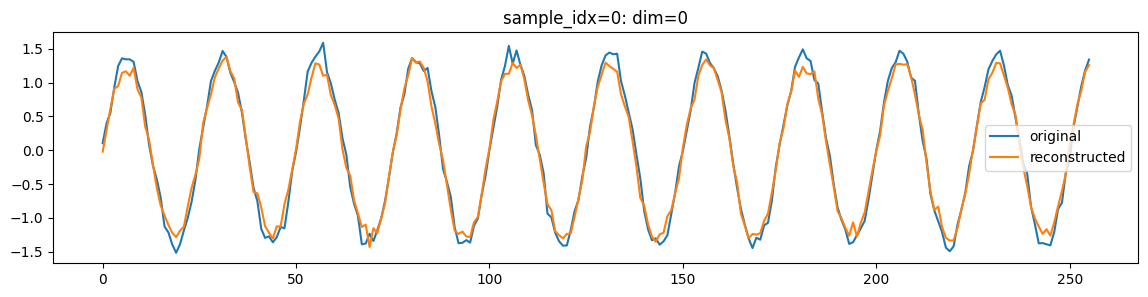

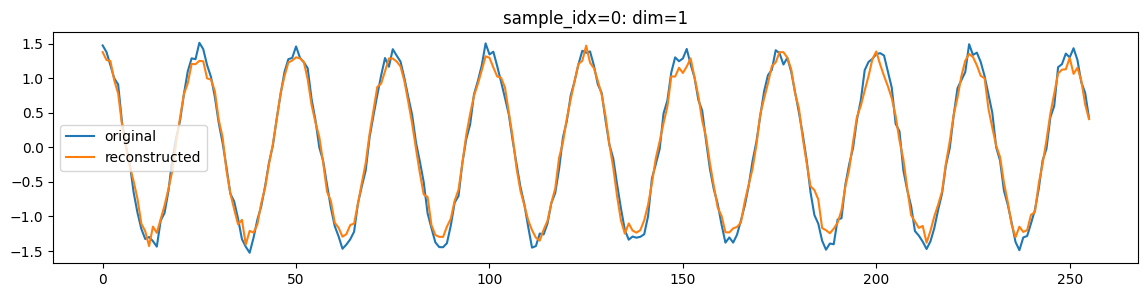

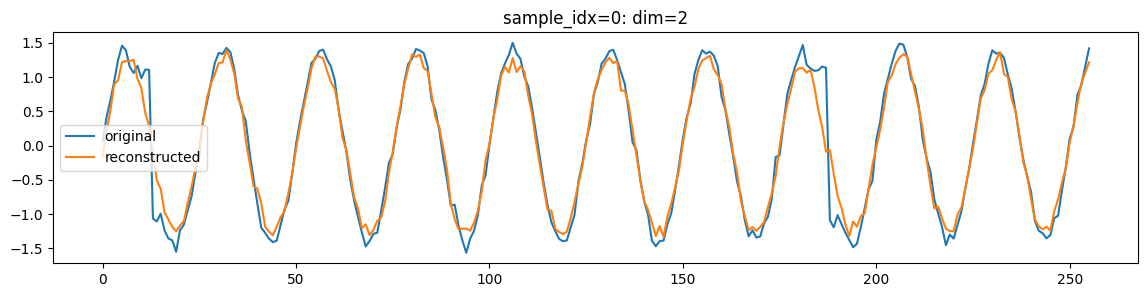

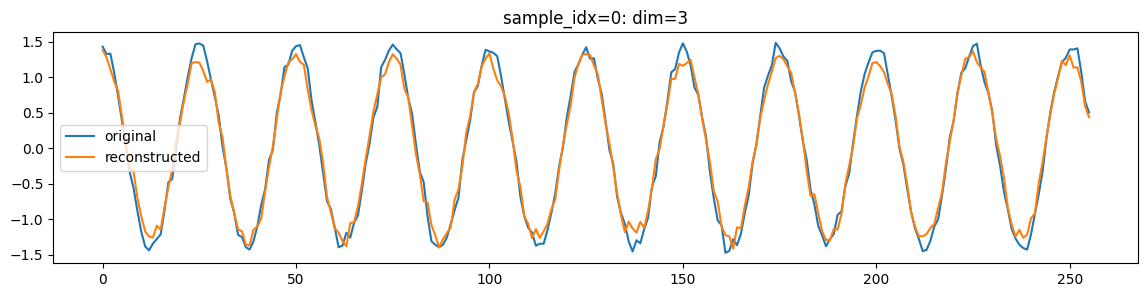

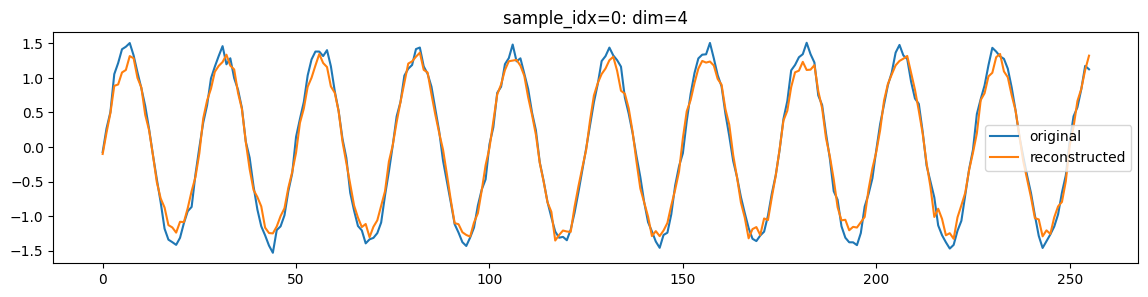

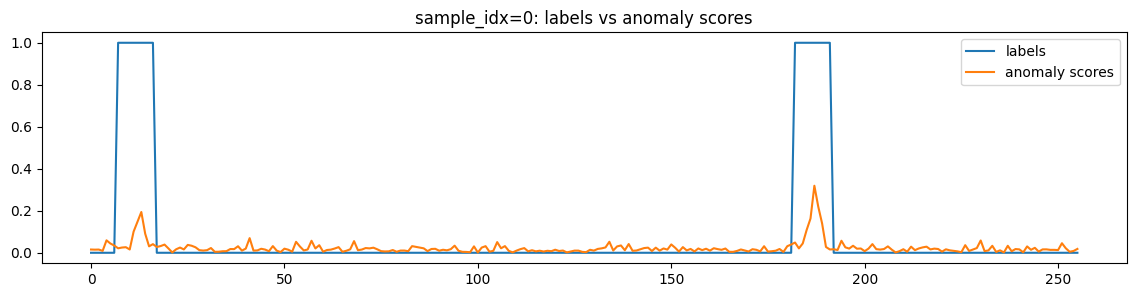

In [17]:
show_example("pattern_shapelet")

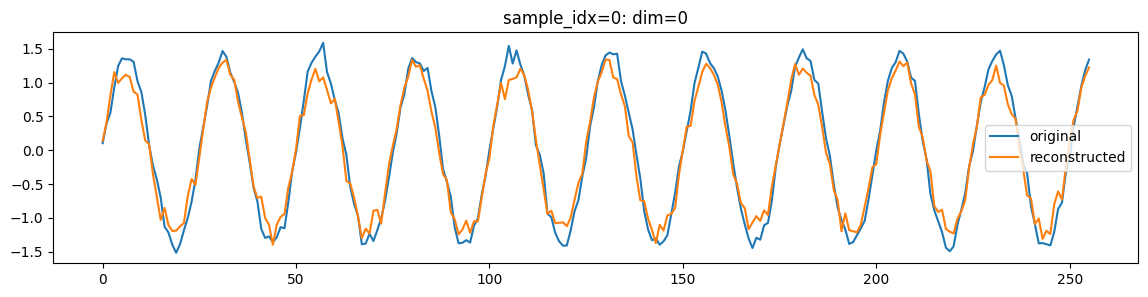

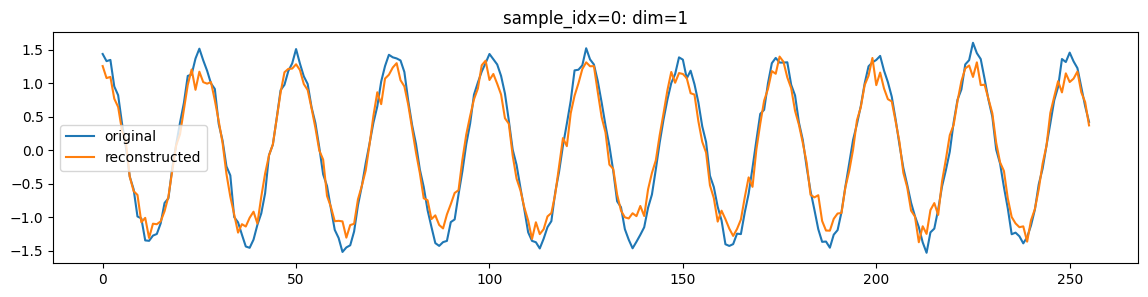

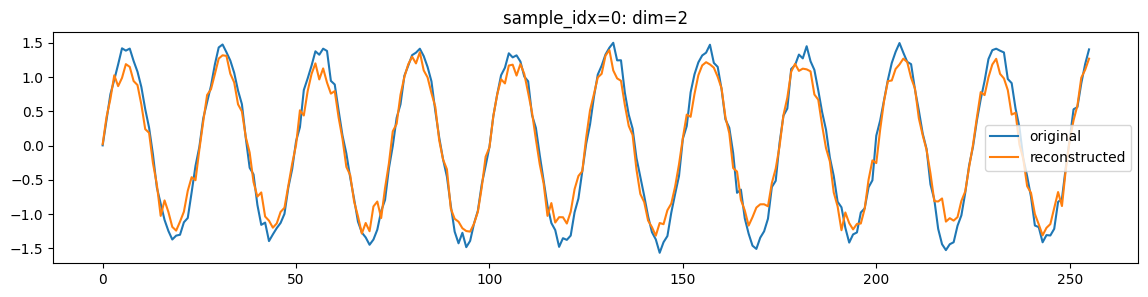

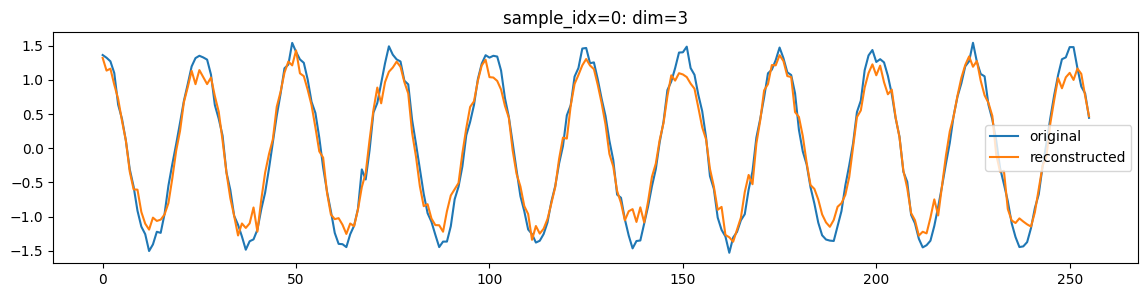

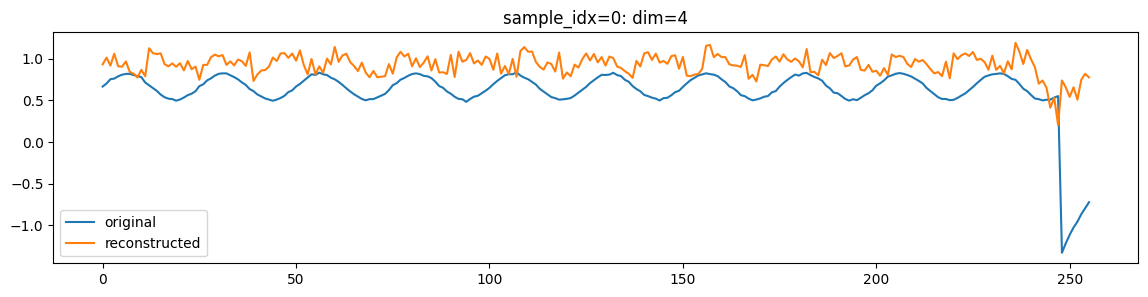

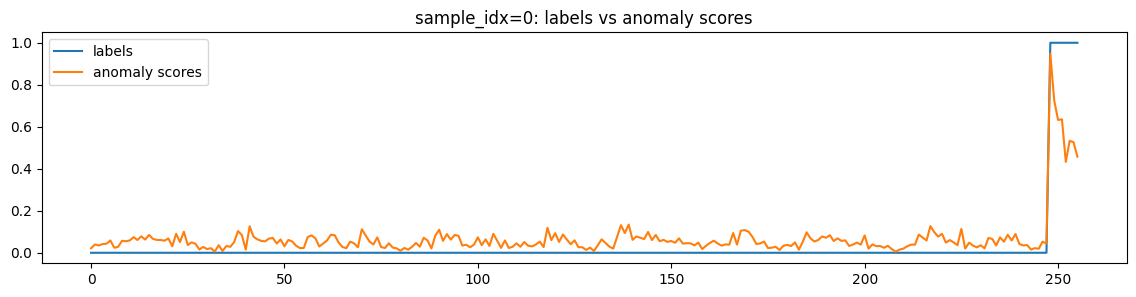

In [18]:
show_example("pattern_trendv2")

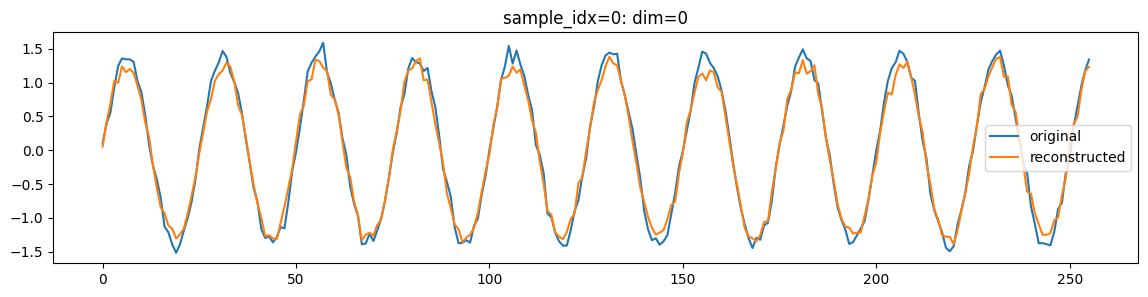

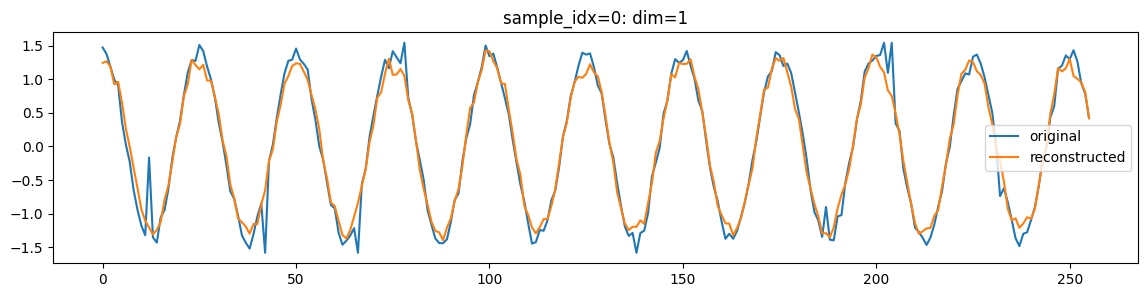

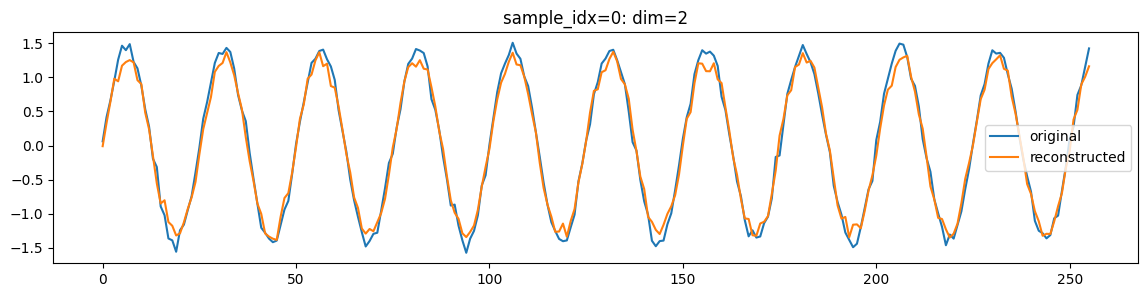

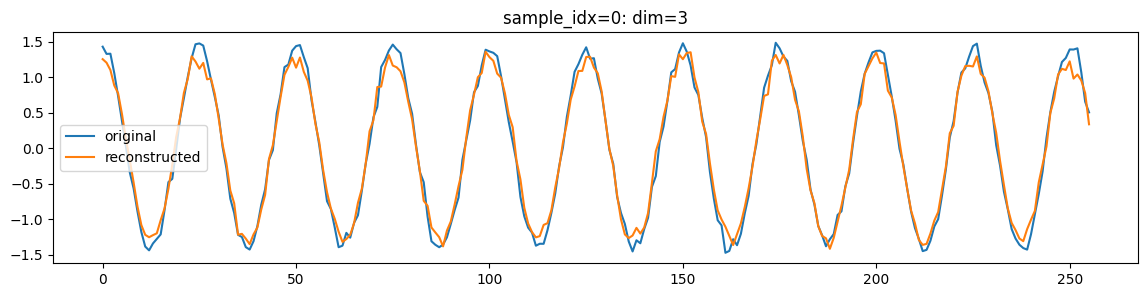

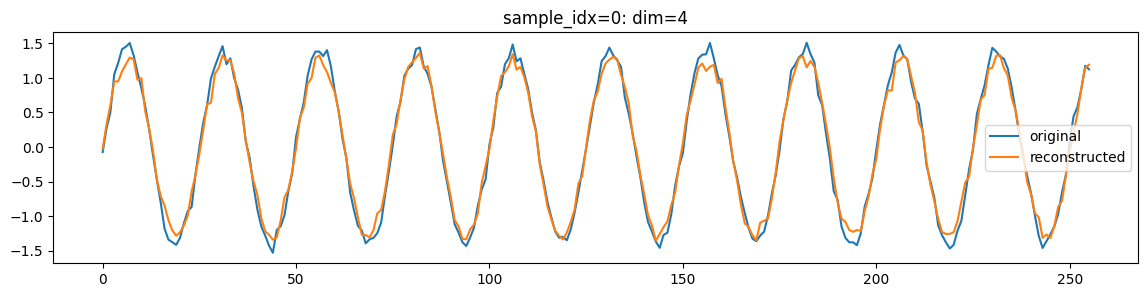

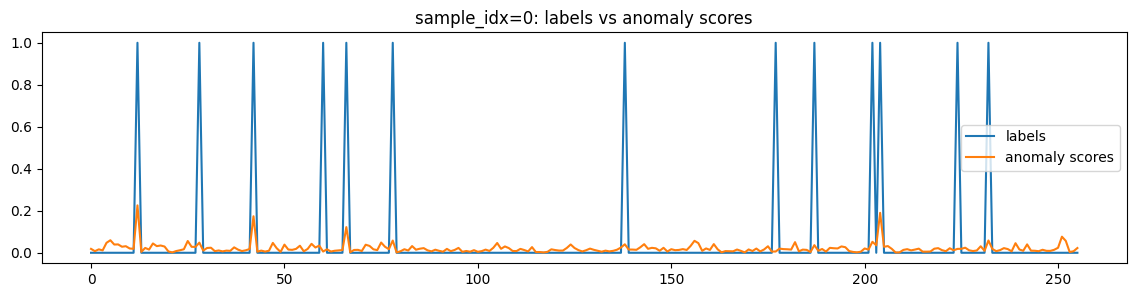

In [19]:
show_example("point_contextual")

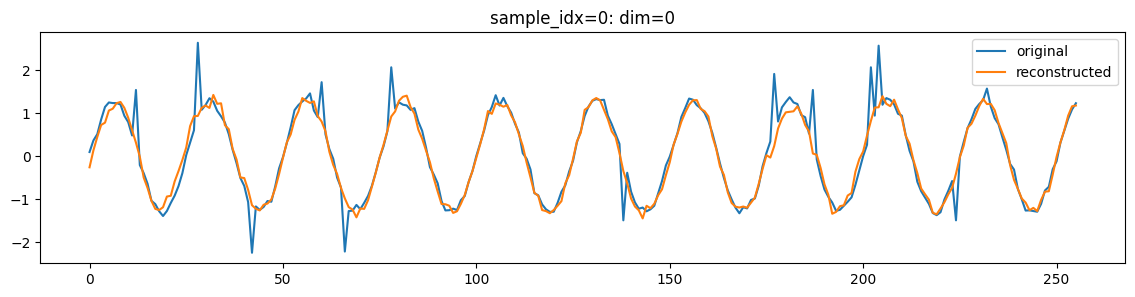

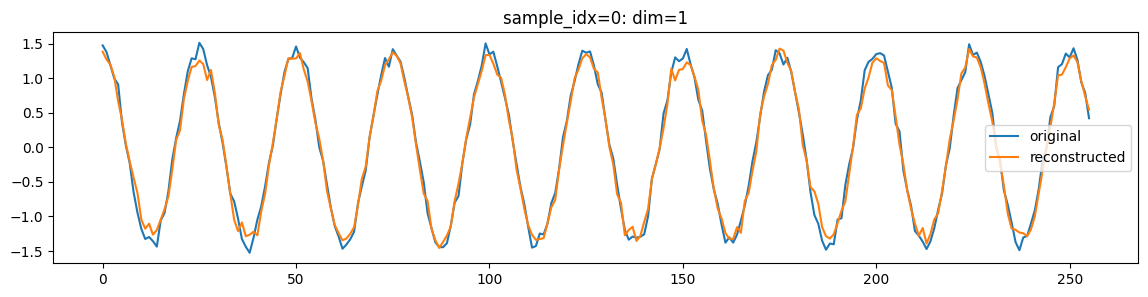

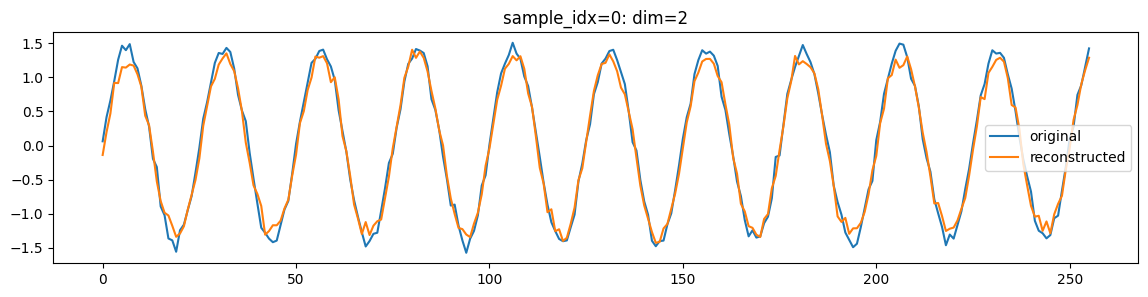

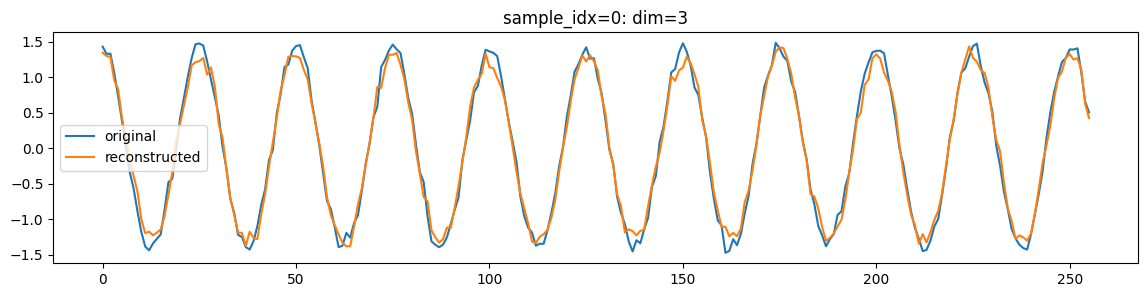

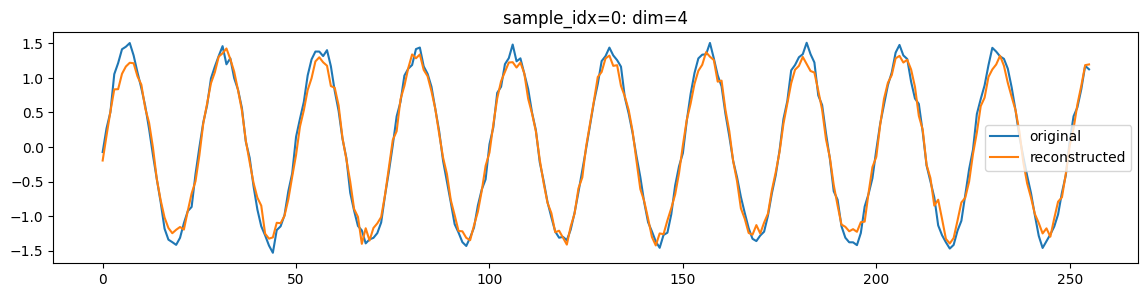

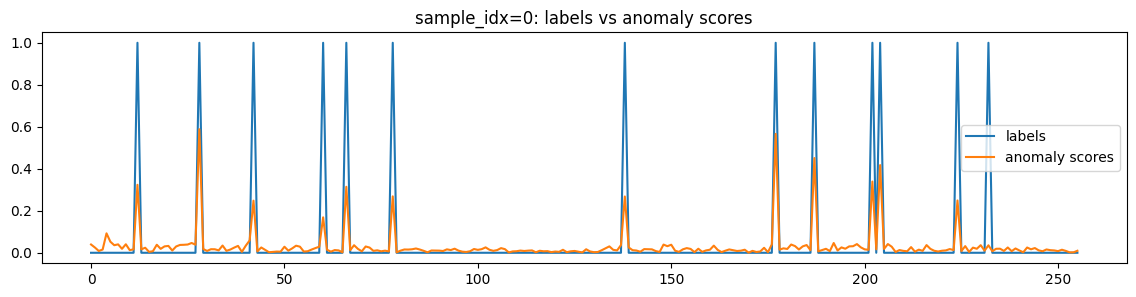

In [20]:
show_example("point_global")